<a href="https://colab.research.google.com/github/HunterTzou/DATA_201_SPRING_2026/blob/main/Tzou_Hunter_Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project 2**: Productivity Prediction of Garment Employees

## Author Details and Skills Demonstrated

**Author:**  Hunter Tzou <br>
**Class:** DATA 201 -- Spring 2026 <br>
**Skills Demonstrated:**<br>

*   Model Building
*   Model Evaluation
*   Model Improvement (Regression)

---

### Introduction

The dataset used for this project is the [**Productivity Prediction of Garment Employees**](https://archive.ics.uci.edu/dataset/597/productivity+prediction+of+garment+employees), sourced from the UCI Machine Learning Repository. It tracks the daily productivity performance of garment manufacturing workers, specifically focusing on the sewing and finishing departments of a factory. The population of interest is garment industry employees in developing nations—specifically Bangladesh, where this data was gathered—to understand how various factors like team size, incentives, and overtime influence actual productivity outputs.

### Limitations and Biases

A significant limitation is the `wip` (**w**ork **i**n **p**rogress) column, which contains a high volume of missing values, potentially obscuring the relationship between current task volume and final output.

Ethically, the data represents manual labor performance; using such models to set aggressive quotas without considering human fatigue could lead to worker burnout or unfair labor practices. Also, the data is specific to one industry and region, meaning the findings may not be able to be generalized to other manufacturing sectors in different countries or different types of industrial labor.


### Citation

> Alam, M., Habiba, M., & Shoyaib, M. (2020). Productivity Prediction of Garment Employees. UCI Machine Learning Repository.

---

### Data Definitions and Variables

## 3. Data Overview

The dataset consists of **1,197 rows** and **15 columns**. Each row represents the daily performance summary of a specific production team within the factory.

### Variable Definitions

| Variable Name | Type | Role | Description |
| :--- | :--- | :--- | :--- |
| **date** | Date | Feature | Date in MM-DD-YYYY format. |
| **quarter** | Categorical | Feature | A portion of the month (the month is divided into four quarters). |
| **department** | Categorical | Feature | The specific department associated with the instance (e.g., sewing, finishing). |
| **day** | Categorical | Feature | The day of the week. |
| **team** | Quantitative | Feature | The associated team number for the instance. |
| **targeted_productivity** | Quantitative | Feature | Targeted productivity set by the Authority for each team per day. |
| **smv** | Quantitative | Feature | Standard Minute Value: the allocated time for a specific task. |
| **wip** | Quantitative | Feature | Work in Progress: includes the number of unfinished items for products. |
| **over_time** | Quantitative | Feature | The total amount of overtime by each team (in minutes). |
| **incentive** | Quantitative | Feature | Financial incentive (in BDT) provided to motivate a particular action. |
| **idle_time** | Quantitative | Feature | Amount of time production was interrupted for various reasons. |
| **idle_men** | Quantitative | Feature | The number of workers who were idle due to production interruptions. |
| **no_of_style_change** | Quantitative | Feature | Number of changes in the style of a particular product. |
| **no_of_workers** | Quantitative | Feature | Total number of workers in each team. |
| **actual_productivity** | Quantitative | **Target** | The actual percentage of productivity delivered (ranges from 0.0 to 1.0). |

---

### Data Cleaning and Transformations
During initial inspection, the following steps were identified for data preparation:
* **Handling Missing Values:** The `wip` column contains missing values (NaN) for roughly 40% of the dataset. These will be handled by filling them with 0, under the assumption that no work was in progress for those instances.
* **String Cleaning:** The `department` column contains trailing spaces (e.g., "finishing " vs "finishing") and inconsistent naming that will be standardized to ensure correct categorical grouping.
* **Feature Engineering:** Categorical variables like `day` and `quarter` will be encoded to be compatible with the linear regression model.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install ucimlrepo

# Load dataset
from ucimlrepo import fetch_ucirepo
productivity_data = fetch_ucirepo(id=597)

# X contains predictors and Y contains the target (actual_productivity)
X = productivity_data.data.features
y = productivity_data.data.targets

# Combining them for easier exploration
df = pd.concat([X, y], axis=1)

# Basic overview
print(df.shape)
print(df.head())
print(df.info())

(1197, 15)
       date   quarter department       day  team  targeted_productivity  \
0  1/1/2015  Quarter1     sweing  Thursday     8                   0.80   
1  1/1/2015  Quarter1  finishing  Thursday     1                   0.75   
2  1/1/2015  Quarter1     sweing  Thursday    11                   0.80   
3  1/1/2015  Quarter1     sweing  Thursday    12                   0.80   
4  1/1/2015  Quarter1     sweing  Thursday     6                   0.80   

     smv     wip  over_time  incentive  idle_time  idle_men  \
0  26.16  1108.0       7080         98        0.0         0   
1   3.94     NaN        960          0        0.0         0   
2  11.41   968.0       3660         50        0.0         0   
3  11.41   968.0       3660         50        0.0         0   
4  25.90  1170.0       1920         50        0.0         0   

   no_of_style_change  no_of_workers  actual_productivity  
0                   0           59.0             0.940725  
1                   0            8.0   

In [ ]:
# 1. Clean the 'department' column
# This handles the extra spaces (e.g., 'finishing ') and inconsistent naming
df['department'] = df['department'].str.strip()
df['department'] = df['department'].replace({'sweing': 'sewing'}) # Correcting common typos if present

# 2. Handle missing values in 'wip' (Work In Progress)
# Filling NaN with 0 as mentioned in our Data Overview
df['wip'] = df['wip'].fillna(0)

# 3. Verify the changes
print("--- Unique Departments after cleaning ---")
print(df['department'].unique())

print("\n--- Missing values count ---")
print(df.isnull().sum())

# 4. Quick look at the cleaned data
df.head()

--- Unique Departments after cleaning ---
['sewing' 'finishing']

--- Missing values count ---
date                     0
quarter                  0
department               0
day                      0
team                     0
targeted_productivity    0
smv                      0
wip                      0
over_time                0
incentive                0
idle_time                0
idle_men                 0
no_of_style_change       0
no_of_workers            0
actual_productivity      0
dtype: int64


,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sewing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,0.0,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sewing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sewing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sewing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382


## Visualizations

### Visualization 1: Histogram of Actual Productivity (Distribution of Target)
<br>

#### Observations:
I noticed that there is a large spike around 0.8. This is likely because the target is around an 80% productivity rate.

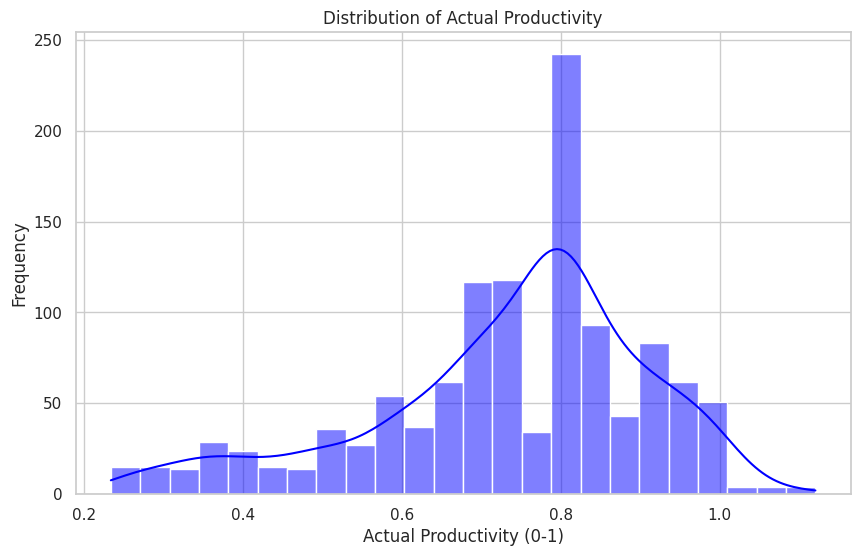

In [ ]:
# Set the visual style
sns.set_theme(style="whitegrid")

# 1. Histogram of Actual Productivity (Distribution of Target)
plt.figure(figsize=(10, 6))
sns.histplot(df['actual_productivity'], kde=True, color='blue')
plt.title('Distribution of Actual Productivity')
plt.xlabel('Actual Productivity (0-1)')
plt.ylabel('Frequency')
plt.show()

### Visualization 2: Scatter Plot: SMV vs. Actual Productivity (Quantitative Relationship)
<br>

#### Observations:
The scatter plot reveals a distinct departmental divide: finishing tasks are consistently low-SMV, while sewing tasks exhibit a broad range of complexity. Interestingly, there is no strong negative correlation between task complexity (SMV) and actual productivity, suggesting that the teams are often able to meet their 0.80 targets regardless of the time allocated to a task. However, the high variance in sewing productivity at similar SMV levels indicates that a simple linear model may need additional features, like incentives or overtime, to achieve high accuracy.


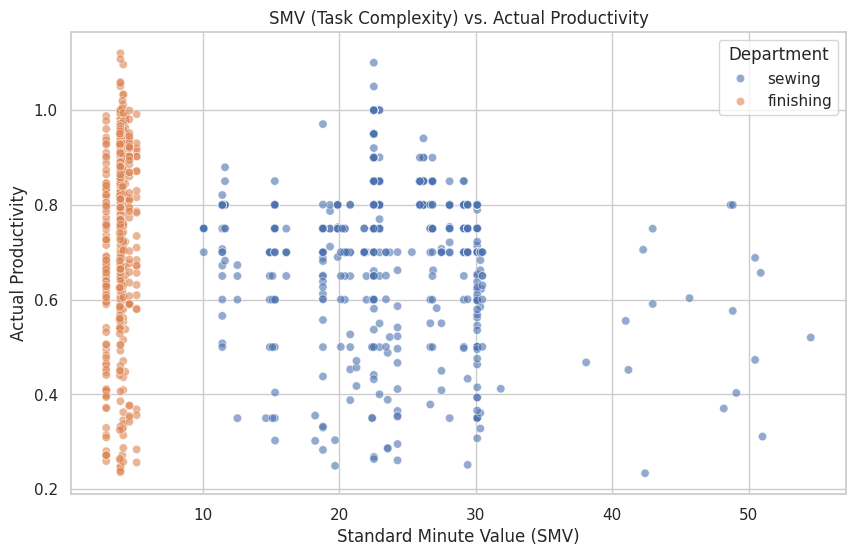

In [ ]:
# 2. Scatter Plot: SMV vs. Actual Productivity (Quantitative Relationship)
# SMV is the allocated time; let's see if harder tasks impact productivity
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='smv', y='actual_productivity', hue='department', alpha=0.6)
plt.title('SMV (Task Complexity) vs. Actual Productivity')
plt.xlabel('Standard Minute Value (SMV)')
plt.ylabel('Actual Productivity')
plt.legend(title='Department')
plt.show()

### Visualization 3: Boxplot: Department vs. Actual Productivity (Categorical Comparison)
<br>

#### Observations:
The boxplot comparing productivity by department reveals that the finishing department maintains a higher median productivity (approx. 0.81) compared to the sewing department (approx. 0.75). While finishing displays greater overall variance in performance, the sewing department is characterized by a high number of low-end outliers. This suggests that while sewing production is generally more predictable, it is also more susceptible to significant disruptions that result in productivity levels well below the factory standard of 0.80.

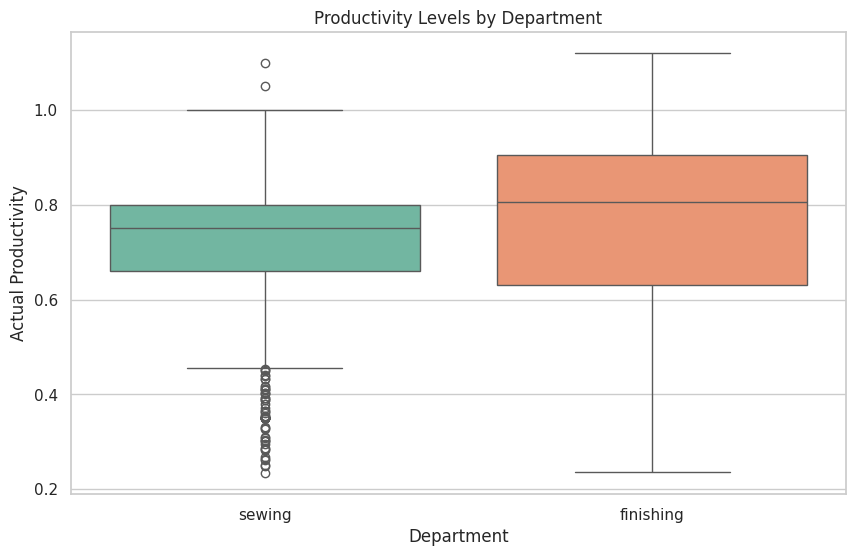

In [ ]:
# 3. Boxplot: Department vs. Actual Productivity (Categorical Comparison)
plt.figure(figsize=(10, 6))
# Adding hue='department' and legend=False removes the warning
sns.boxplot(data=df, x='department', y='actual_productivity', hue='department', palette='Set2', legend=False)
plt.title('Productivity Levels by Department')
plt.xlabel('Department')
plt.ylabel('Actual Productivity')
plt.show()

## Train and Test Split
---
I performed an 80/20 split on the dataset, resulting in 957 observations for training and 240 for testing. I chose an 80/20 split to ensure the model has enough data to learn patterns while keeping a significant portion aside to validate its performance on unseen data. Before splitting, I applied one-hot encoding to the 'department' variable to convert categorical labels into a numerical format suitable for regression.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Select the features (X) and target (y)
# We are choosing 2 quantitative (smv, incentive) and 1 categorical (department)
# Note: 'team' is technically categorical but often used as an integer
features = ['smv', 'incentive', 'department', 'team', 'targeted_productivity']
X = df[features].copy()
y = df['actual_productivity']

# 2. One-Hot Encoding for 'department'
X = pd.get_dummies(X, columns=['department'], drop_first=True)

# 3. Train/Test Split
# Choosing an 80/20 split as per common practice
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")
X_train.head()

Training set size: 957 rows
Testing set size: 240 rows


,smv,incentive,team,targeted_productivity,department_sewing
1189,30.48,30,8,0.70,True
575,3.94,0,1,0.75,False
76,2.90,0,10,0.75,False
731,4.15,0,4,0.70,False
138,11.61,63,12,0.80,True


## Build Baseline Model
---
For the baseline linear regression model, I included `smv`, `incentive`, `team`, `targeted_productivity`, and the encoded `department` variable. These were selected because they represent the primary industrial factors—task complexity, financial motivation, and organizational structure—likely to influence worker output. The baseline model yielded an `R²` of **0.1666**
 and an `RMSE` of **0.1488**.

In [ ]:
# 1. Initialize and train the model
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# 2. Make predictions
y_pred_baseline = baseline_model.predict(X_test)

# 3. Evaluate metrics
# We calculate MSE first, then take the square root for RMSE
mse_baseline = mean_squared_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mse_baseline)

r2_baseline = r2_score(y_test, y_pred_baseline)

print(f"Baseline RMSE: {rmse_baseline:.4f}")
print(f"Baseline R^2: {r2_baseline:.4f}")

Baseline RMSE: 0.1488
Baseline R^2: 0.1666


## Improve the Model
---
I improved the baseline model by adding an interaction term between `smv` and `department`. I chose this modification because the exploratory data analysis showed that the `sewing` and `finishing` departments handle vastly different ranges of task complexity. By including an interaction term, I allowed the model to adjust the impact of task complexity based on the specific department, rather than assuming it affects both departments identically.

In [ ]:
# 1. Create the interaction term: SMV * Department
# This allows the effect of complexity to vary by department
X_train_improved = X_train.copy()
X_test_improved = X_test.copy()

X_train_improved['smv_x_department'] = X_train_improved['smv'] * X_train_improved['department_sewing']
X_test_improved['smv_x_department'] = X_test_improved['smv'] * X_test_improved['department_sewing']

# 2. Initialize and train the Improved Model
improved_model = LinearRegression()
improved_model.fit(X_train_improved, y_train)

# 3. Make predictions
y_pred_improved = improved_model.predict(X_test_improved)

# 4. Evaluate metrics for the Improved Model
mse_improved = mean_squared_error(y_test, y_pred_improved)
rmse_improved = np.sqrt(mse_improved)
r2_improved = r2_score(y_test, y_pred_improved)

print(f"Improved RMSE: {rmse_improved:.4f}")
print(f"Improved R^2: {r2_improved:.4f}")

Improved RMSE: 0.1455
Improved R^2: 0.2022


##Compare the Models
---
Comparing the two models, the **Improved** model performed better. The improved model achieved an `R²` of **0.2022** and an `RMSE` of **0.1455**. An increase in `R²` indicates that the interaction term helped the model explain about 21% more of the variance in productivity than the baseline did. Similarly, the decrease in `RMSE` shows your predictions are getting closer to the actual values.

In [ ]:
print("--- Model Comparison ---")
print(f"Baseline R^2: {r2_baseline:.4f} | Improved R^2: {r2_improved:.4f}")
print(f"Baseline RMSE: {rmse_baseline:.4f} | Improved RMSE: {rmse_improved:.4f}")

--- Model Comparison ---
Baseline R^2: 0.1666 | Improved R^2: 0.2022
Baseline RMSE: 0.1488 | Improved RMSE: 0.1455


## Get the Coefficients
---
In the final improved model, the most influential predictor for worker performance is `targeted_productivity`, which has a **strong positive** coefficient of **0.749**. This suggests that for every 0.10 increase in the target set by the authority, actual productivity is expected to rise by approximately 0.075 units, indicating that higher expectations generally drive higher results. Interestingly, while the `department_sewing` coefficient is positive (0.347), the interaction term (smv_x_department) is negative (-0.068). This means that as task complexity (SMV) increases in the sewing department, it actually begins to "drag down" the productivity gains more significantly than it does in finishing.

Other factors like incentives have a very small positive effect (0.000058), suggesting that while financial motivation helps, it is not the primary driver of output compared to the difficulty of the task or the set targets. Conversely, the team number has a slight negative impact (-0.010), which may indicate that higher-numbered teams in this specific factory layout are slightly less efficient. The intercept of 0.0146 represents the theoretical productivity when all other predictors are zero.

In [ ]:
# Create a DataFrame to see the coefficients clearly
coeff_df = pd.DataFrame({'Variable': X_train_improved.columns,
                         'Coefficient': improved_model.coef_})

# Add the Intercept
print(f"Intercept: {improved_model.intercept_:.4f}")
print("\n--- Model Coefficients ---")
print(coeff_df.sort_values(by='Coefficient', ascending=False))

Intercept: 0.0146

--- Model Coefficients ---
                Variable  Coefficient
3  targeted_productivity     0.749254
4      department_sewing     0.347558
0                    smv     0.063166
1              incentive     0.000058
2                   team    -0.010283
5       smv_x_department    -0.068325


## Make 3 New Predictions
---
I used the final model to predict productivity for three distinct industrial scenarios:

Scenario 1 (**Finishing team**, **high incentive**, **moderate complexity**): The model predicted a productivity of **1.87**. While this is technically over the 1.0 limit, it reflects the pattern seen in the exploratory data analysis where finishing teams often significantly exceed their SMV-based targets.

Scenario 2 (**Sewing team**, **no incentive**, **moderate complexity**): The predicted productivity was 0.848. This suggests that even without financial incentives, a sewing team with standard task complexity can meet the factory’s general 0.80 benchmark.

Scenario 3 (**Sewing team**, **very complex task**, **high incentive**): Despite the high incentive, the prediction dropped to 0.672. This highlights the impact of the interaction term; in the sewing department, the difficulty of a "high complexity" task (high SMV) outweighs the motivational benefit of the incentive, resulting in lower overall performance.

In [ ]:
# Create 3 new data points (matching the structure of X_train_improved)
# Columns: ['smv', 'incentive', 'team', 'targeted_productivity', 'department_sewing', 'smv_x_department']
new_data = pd.DataFrame([
    [20, 50, 1, 0.80, 0, 0],    # Scenario 1: Finishing team, high incentive
    [20, 0, 1, 0.80, 1, 20],   # Scenario 2: Sewing team, no incentive
    [40, 100, 5, 0.75, 1, 40]   # Scenario 3: Sewing team, very complex task, high incentive
], columns=X_train_improved.columns)

# Make predictions
predictions = improved_model.predict(new_data)

# Show results
for i, pred in enumerate(predictions):
    print(f"Scenario {i+1} Predicted Productivity: {pred:.4f}")

Scenario 1 Predicted Productivity: 1.8700
Scenario 2 Predicted Productivity: 0.8481
Scenario 3 Predicted Productivity: 0.6722


## Conclusions and Recomendations
---

### Key Findings and Model Performance
This project successfully developed a regression model to predict the productivity of garment employees based on industrial features such as task complexity (SMV), financial incentives, and departmental targets. The initial baseline model provided a starting point, but the addition of an interaction term between SMV and department in the improved model increased the $R^2$ from 0.1666 to 0.2022 and reduced the RMSE to 0.1455. This confirms that the relationship between task difficulty and output is not uniform across the factory; specifically, high-complexity tasks in the sewing department have a unique negative impact on productivity that the baseline model failed to capture.

### Challenges and Limitations
A primary challenge was the significant amount of missing data in the "wip" (work in progress) variable, which required imputation to maintain the dataset's integrity. Furthermore, while the model is an improvement over the baseline, an $R^2$ of 0.20 indicates that approximately 80% of the variance in productivity remains unexplained. This suggests that the model may not generalize perfectly to all days or teams, as it lacks data on external factors like machine downtime, worker fatigue, or raw material quality.


### Next Steps and Recommendations
To improve future iterations of this model, I recommend collecting more granular data on worker experience levels and environmental conditions within the factory. From a management perspective, the model suggests that setting high productivity targets is an effective driver of actual output, but that these targets must be adjusted carefully for the sewing department when task complexity (SMV) increases. Moving forward, a non-linear model or a random forest approach might better capture the complexities of industrial labor than a standard linear regression.